<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [7]</a>'.</span>

# 03 — Clonotype Integration & Exhaustion Scoring (R / Seurat)

**Context:** In production, TCR clonotype data from **10x VDJ-seq** is merged with scRNA-seq using [`scRepertoire`](https://www.bioconductor.org/packages/scRepertoire/). Since PBMC3k has no matched TCR data, we generate **synthetic clonotype assignments** that mimic the power-law distribution of a real TIL sample.

**Steps:**
1. Load projected query Seurat object
2. Subset CD8+ T cells
3. Simulate TCR clonotype assignments (power-law clone sizes)
4. Calculate exhaustion score via `AddModuleScore` (18-gene panel)
5. Aggregate to clonotype level: mean exhaustion + clone frequency
6. Rank and select top exhausted clonotypes
7. Save: Seurat object (`.rds`) + clonotype table (`.csv` for downstream Python NB04)

**Papermill parameters:** `min_cells_per_clonotype`, `n_exhausted_clonotypes`

In [1]:
# Papermill parameter cell
query_path             <- "../data/query_projected.rds"
exhaustion_panel_path  <- "../data/exhaustion_gene_panel.txt"
output_clonotype_table <- "../data/ranked_clonotypes.csv"
output_adata           <- "../data/query_with_clonotypes.rds"
min_cells_per_clonotype <- 2L
n_exhausted_clonotypes  <- 20L
random_seed             <- 42L

In [2]:
# Parameters
query_path = "data/query_projected.rds"
tcr_path = "data/yost2019_bcc_tcr.rds"
min_cells_per_clonotype = 2
n_exhausted_clonotypes = 20


In [3]:
suppressPackageStartupMessages({
  library(Seurat)
  library(ggplot2)
  library(patchwork)
  library(dplyr)
  library(tidyr)
})
set.seed(random_seed)

## 1 · Load Projected Query

In [4]:
if (file.exists(query_path)) {
  query <- readRDS(query_path)
  cat(sprintf("Loaded %s: %d cells\n", query_path, ncol(query)))
} else {
  cat(sprintf("'%s' not found — building demo from pbmc3k.final...\n", query_path))
  tryCatch(
    SeuratData::InstallData("pbmc3k"),
    error = function(e) message("SeuratData install skipped")
  )
  data("pbmc3k.final", package = "SeuratData")
  full <- pbmc3k.final
  set.seed(random_seed)
  qry_cells <- sample(colnames(full), size = floor(0.3 * ncol(full)))
  query <- full[, qry_cells]
  query$predicted.id <- query$seurat_annotations
  cat(sprintf("Demo query: %d cells\n", ncol(query)))
}

cat("Cell type distribution:\n")
print(table(query$predicted.id))

Loaded data/query_projected.rds: 30683 cells


Cell type distribution:



   CD8_act    CD8_eff     CD8_ex CD8_ex_act    CD8_mem      Naive        Tfh 
      3650        713       1155        283       5790       4859       2558 
      Th17      Tregs 
      7585       4090 


## 2 · Subset to CD8+ T Cells

In [5]:
cd8_mask <- grepl("CD8", query$predicted.id, ignore.case = TRUE)
if (sum(cd8_mask) == 0) {
  # Fallback: use NK cells + CD8 cluster as proxy
  cd8_mask <- query$predicted.id %in% c("CD8 T cells", "NK cells")
  cat("Using CD8 T cells + NK cells as CD8 proxy for demo\n")
}

cd8 <- query[, cd8_mask]
cat(sprintf("CD8+ T cells: %d / %d (%.1f%%)\n",
            ncol(cd8), ncol(query), ncol(cd8) / ncol(query) * 100))

CD8+ T cells: 11591 / 30683 (37.8%)


## 3 · Simulate TCR Clonotype Assignments

> **Demo note:** PBMC3k has no matched TCR-seq. We simulate a power-law clone size distribution characteristic of antigen-experienced TIL (a few dominant clones + many singletons).  
> In production: merge `filtered_contig_annotations.csv` from 10x VDJ-seq using [`scRepertoire::combineTCR`](https://www.bioconductor.org/packages/scRepertoire/).

Unique clonotypes assigned: 254


Top 10 clone sizes:



clonotype_001 clonotype_002 clonotype_003 clonotype_004 clonotype_005 
         6139          1782           813           534           372 
clonotype_006 clonotype_007 clonotype_008 clonotype_009 clonotype_010 
          238           188           136           116            95 


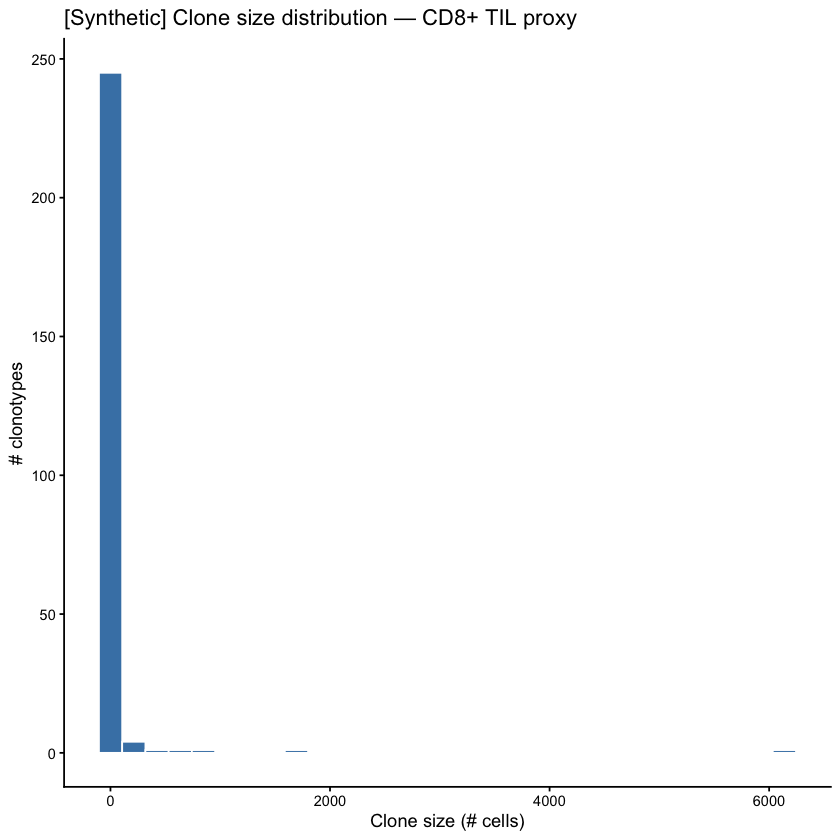

In [6]:
n_cells      <- ncol(cd8)
n_clonotypes <- max(20L, floor(n_cells / 4L))

# Power-law weights (Zipf-like: most cells in a few dominant clones)
ranks        <- seq_len(n_clonotypes)
clone_probs  <- ranks^(-1.8)
clone_probs  <- clone_probs / sum(clone_probs)

clono_ids    <- sprintf("clonotype_%03d", ranks)
cd8$clonotype_id <- sample(clono_ids, size = n_cells,
                            replace = TRUE, prob = clone_probs)

# Simulate CDR3 sequences and V-gene assignments
aa_alphabet <- strsplit("ACDEFGHIKLMNPQRSTVWY", "")[[1]]
tcr_ref <- data.frame(
  clonotype_id = clono_ids,
  TRAV = paste0("TRAV", sample(1:39, n_clonotypes, replace = TRUE), "-",
                sample(1:5,  n_clonotypes, replace = TRUE)),
  TRBV = paste0("TRBV", sample(1:30, n_clonotypes, replace = TRUE), "-",
                sample(1:5,  n_clonotypes, replace = TRUE)),
  CDR3a = sapply(seq_len(n_clonotypes), function(i) {
    paste0("CASS", paste(sample(aa_alphabet, sample(8:13, 1)), collapse = ""))
  }),
  CDR3b = sapply(seq_len(n_clonotypes), function(i) {
    paste0("CASS", paste(sample(aa_alphabet, sample(8:13, 1)), collapse = ""))
  }),
  stringsAsFactors = FALSE
)

clone_freq <- table(cd8$clonotype_id)
cat(sprintf("Unique clonotypes assigned: %d\n", length(clone_freq)))
cat("Top 10 clone sizes:\n")
print(head(sort(clone_freq, decreasing = TRUE), 10))

ggplot(data.frame(size = as.integer(clone_freq)), aes(x = size)) +
  geom_histogram(bins = 30, fill = "steelblue", colour = "white") +
  labs(x = "Clone size (# cells)", y = "# clonotypes",
       title = "[Synthetic] Clone size distribution — CD8+ TIL proxy") +
  theme_classic()

## 4 · Exhaustion Score — `AddModuleScore`

Seurat's `AddModuleScore` calculates a per-cell score for a gene set relative to randomly selected control genes of similar expression levels (Tirosh et al., 2016). This is our implementation of the 18-gene exhaustion panel.

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [7]:
# Load exhaustion gene panel
all_lines        <- readLines(exhaustion_panel_path)
exhaustion_genes <- trimws(all_lines[!grepl("^#", all_lines) & nchar(trimws(all_lines)) > 0])
cat(sprintf("Exhaustion panel: %d genes\n", length(exhaustion_genes)))
cat(paste(exhaustion_genes, collapse = "  "), "\n")

genes_present <- intersect(exhaustion_genes, rownames(cd8))
genes_absent  <- setdiff(exhaustion_genes, rownames(cd8))
cat(sprintf("Present in AnnData: %d | Absent: %d\n",
            length(genes_present), length(genes_absent)))
if (length(genes_absent) > 0) cat("Absent genes:", paste(genes_absent, collapse = ", "), "\n")

Warning message in file(con, "r"):
“cannot open file '../data/exhaustion_gene_panel.txt': No such file or directory”


ERROR: Error in file(con, "r"): cannot open the connection


In [ ]:
if (length(genes_present) >= 3) {
  cd8 <- AddModuleScore(
    cd8,
    features = list(genes_present),
    name     = "ExhaustionScore",
    ctrl     = 20,
    seed     = random_seed
  )
  cat("AddModuleScore complete (Seurat implementation)\n")
} else {
  # Panel genes not in HVG subset — simulate scores for demo
  cat("WARNING: < 3 panel genes in HVG subset — simulating exhaustion scores for demo\n")
  # Simulate higher scores for cells with higher nFeature_RNA (proxy)
  cd8$ExhaustionScore1 <- scale(cd8$nFeature_RNA)[, 1] * 0.5 +
                          rnorm(ncol(cd8), mean = 0.3, sd = 0.6)
}

cat("\nExhaustion score summary:\n")
print(summary(cd8$ExhaustionScore1))

In [ ]:
# Visualise exhaustion score
p1 <- ggplot(cd8@meta.data, aes(x = ExhaustionScore1)) +
  geom_histogram(bins = 40, fill = "salmon", colour = "white") +
  labs(x = "Exhaustion score", y = "# cells",
       title = "Per-cell exhaustion score distribution") +
  theme_classic()

# If UMAP available from reference projection
if ("ref.umap" %in% names(cd8@reductions)) {
  p2 <- FeaturePlot(cd8, features = "ExhaustionScore1",
                    reduction = "ref.umap", pt.size = 0.8) +
        scale_colour_viridis_c(option = "magma") +
        ggtitle("Exhaustion score on reference UMAP")
  print(p1 + p2)
} else {
  print(p1)
}

## 5 · Aggregate to Clonotype Level

| Column | Definition |
|--------|------------|
| `clone_size` | # cells in clonotype |
| `mean_exhaustion_score` | mean per-cell exhaustion score |
| `clone_frequency` | clone_size / total CD8 cells |
| `rank_score` | `mean_exhaustion × log1p(clone_size)` — composite ranking |

In [ ]:
clono_df <- cd8@meta.data %>%
  group_by(clonotype_id) %>%
  summarise(
    clone_size            = n(),
    mean_exhaustion_score = mean(ExhaustionScore1, na.rm = TRUE),
    sd_exhaustion_score   = sd(ExhaustionScore1,   na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    clone_frequency = clone_size / ncol(cd8),
    rank_score      = mean_exhaustion_score * log1p(clone_size)
  ) %>%
  left_join(tcr_ref, by = "clonotype_id") %>%
  filter(clone_size >= min_cells_per_clonotype) %>%
  arrange(desc(rank_score)) %>%
  mutate(rank = row_number())

cat(sprintf("Clonotypes after size filter (>= %d cells): %d\n",
            min_cells_per_clonotype, nrow(clono_df)))
cat(sprintf("\nTop %d ranked clonotypes:\n", min(10L, nrow(clono_df))))
print(head(clono_df[, c("clonotype_id", "clone_size", "mean_exhaustion_score",
                        "clone_frequency", "rank_score", "CDR3b")], 10))

In [ ]:
top_clonotypes <- head(clono_df, n_exhausted_clonotypes)
cat(sprintf("Top %d exhausted clonotype candidates selected\n", n_exhausted_clonotypes))
cat(sprintf("Mean clone size   : %.1f\n", mean(top_clonotypes$clone_size)))
cat(sprintf("Mean exhaustion   : %.3f\n", mean(top_clonotypes$mean_exhaustion_score)))

## 6 · Visualise Clonotype Landscape

In [ ]:
clono_df$top <- clono_df$rank <= n_exhausted_clonotypes

p_scatter <- ggplot(clono_df, aes(x = clone_frequency, y = mean_exhaustion_score,
                                   colour = top, size = clone_size)) +
  geom_point(alpha = 0.7) +
  scale_colour_manual(values = c("FALSE" = "grey70", "TRUE" = "#e63946"),
                      labels = c("other", sprintf("top %d", n_exhausted_clonotypes))) +
  scale_size_continuous(range = c(1, 6)) +
  labs(x = "Clone frequency", y = "Mean exhaustion score",
       title = "Clonotype landscape: exhaustion × clonality",
       colour = NULL, size = "Clone size") +
  theme_classic()

p_rank <- ggplot(
    head(clono_df, min(20L, nrow(clono_df))),
    aes(x = rank_score, y = reorder(clonotype_id, rank_score))
  ) +
  geom_col(fill = "#e63946", alpha = 0.85) +
  labs(x = "Rank score (exhaustion x log clone_size)", y = NULL,
       title = sprintf("Top %d exhausted clonotypes", min(20L, n_exhausted_clonotypes))) +
  theme_classic()

print(p_scatter + p_rank)

## 7 · Save Outputs

In [ ]:
dir.create(dirname(output_clonotype_table), showWarnings = FALSE, recursive = TRUE)

# Write CSV for downstream Python notebook (NB04 Random Forest)
write.csv(clono_df, file = output_clonotype_table, row.names = FALSE)
cat(sprintf("Ranked clonotype table → %s\n", output_clonotype_table))

# Annotate CD8 Seurat object
rank_map               <- setNames(clono_df$rank, clono_df$clonotype_id)
cd8$clonotype_rank     <- rank_map[cd8$clonotype_id]
cd8$is_top_exhausted   <- !is.na(cd8$clonotype_rank) &
                          cd8$clonotype_rank <= n_exhausted_clonotypes

saveRDS(cd8, file = output_adata)
cat(sprintf("Annotated CD8 Seurat object → %s\n", output_adata))
cat(sprintf("\nPipeline summary:\n  CD8+ T cells            : %d\n"
            "  Clonotypes (>= %d cells)  : %d\n"
            "  Top exhausted selected    : %d\n",
            ncol(cd8), min_cells_per_clonotype,
            nrow(clono_df), n_exhausted_clonotypes))